In [ ]:
import pandas as pd
import numpy as np
from rouge_score import rouge_scorer
from bert_score import score
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from bert_score import plot_example

pd.set_option('display.max_colwidth', None)

print("Semua library berhasil di-import!")

/Users/macbookpro/Documents/Skripsi_RAG_120510220041/RAG---Academic-Chatbot-information/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/macbookpro/Documents/Skripsi_RAG_120510220041/RAG---Academic-Chatbot-information/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Semua library berhasil di-import!


In [ ]:
file_path = 'Intrinsic-evaluation.xlsx'

# Membaca Excel
df = pd.read_excel(file_path)

# Membersihkan data: Mengisi sel kosong dengan teks kosong agar tidak error
df['Jawaban Chatbot'] = df['Jawaban Chatbot'].fillna("")
df['Kalimat Referensi'] = df['Kalimat Referensi'].fillna("")

print(f"Data berhasil dimuat.")
print(f"Total baris data: {len(df)}")
print("\nContoh 3 baris pertama:")
display(df.head(3))

✅ Data berhasil dimuat.
📊 Total baris data: 20

Contoh 3 baris pertama:


,Kode,Pertanyaan User,Jawaban Chatbot,Kalimat Referensi
0,Q1,Draft judul SUP cukup berisi bab apa?,"Untuk pengajuan judul melalui PACIS, file draft SUP yang diunggah cukup berisi Bab 1 saja. Format yang dibutuhkan meliputi: Cover, Lembar pengesahan (sudah ditandatangani), dan Latar belakang (sekitar 3 lembar).","File draft SUP yang diupload cukup sampe bab 1 aja. Bab 1 nya juga ga perlu full, 3 lembar juga cukup – Formatnya : cover – lembar pengesahan (udah di TTD dosbing) – latar belakang"
1,Q2,Minta link bit.ly untuk upload surat konversi magang yang sudah ditandatangani,Anda dapat mengunggah surat yang sudah ditandatangani dosen pembimbing magang melalui tautan berikut: https://bit.ly/UploadFormKonversiMagang,Surat yang sudah di tandatangan dosen pembimbing magang dapat di submit melalui link https://bit.ly/UploadFormKonversiMagang.
2,Q3,berapa SKS yang didapat buat mata kuliah Seminar Bisnis Digital dalam konversi magang?,Mata kuliah Seminar Bisnis Digital dalam konversi magang memiliki bobot 1 SKS. Hal ini berlaku untuk berbagai skema konversi (Magang Industri Digital maupun Usaha Rintisan).,SEMINAR BISNIS DIGITAL = 1 SKS


In [ ]:
print("📊 Sedang menyusun Tabel Detail Lengkap (Prediksi, Referensi, & Breakdown Score)...")

# BAGIAN 1: Hitung Ulang Breakdown ROUGE
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

r1_p, r1_r, r1_f = [], [], []
r2_p, r2_r, r2_f = [], [], []
rl_p, rl_r, rl_f = [], [], []

for index, row in df.iterrows():
    cand = str(row['Jawaban Chatbot'])
    ref = str(row['Kalimat Referensi'])
    
    scores = scorer.score(ref, cand)
    
    # ROUGE-1
    r1_p.append(scores['rouge1'].precision)
    r1_r.append(scores['rouge1'].recall)
    r1_f.append(scores['rouge1'].fmeasure)
    
    # ROUGE-2
    r2_p.append(scores['rouge2'].precision)
    r2_r.append(scores['rouge2'].recall)
    r2_f.append(scores['rouge2'].fmeasure)
    
    # ROUGE-L (LCS)
    rl_p.append(scores['rougeL'].precision)
    rl_r.append(scores['rougeL'].recall)
    rl_f.append(scores['rougeL'].fmeasure)

# Insert ke daat frame
df['R1_Precision'] = r1_p
df['R1_Recall'] = r1_r
df['R1_F1'] = r1_f

df['R2_Precision'] = r2_p
df['R2_Recall'] = r2_r
df['R2_F1'] = r2_f

df['RL_Precision'] = rl_p
df['RL_Recall'] = rl_r
df['RL_F1'] = rl_f

# BAGIAN 2: Menyusun Urutan Kolom

target_order = [
    'Kode',
    'Pertanyaan User',      
    'Jawaban Chatbot',      
    'Kalimat Referensi',    
    
    'R1_Precision', 'R1_Recall', 'R1_F1',
    
    'R2_Precision', 'R2_Recall', 'R2_F1',
    
    'RL_Precision', 'RL_Recall', 'RL_F1',
]

# Filter kolom
available_cols = [c for c in target_order if c in df.columns]
final_df = df[available_cols].copy()

# Rename kolom 
final_df = final_df.rename(columns={
    'Jawaban Chatbot': 'Kalimat Prediksi (Chatbot)',
    'R1_F1': 'R1_F-Measure',
    'R2_F1': 'R2_F-Measure',
    'RL_F1': 'RL_F-Measure'
})

final_df.insert(0, 'No', range(1, len(final_df) + 1))

# --- BAGIAN 3: Formatting & Export ---

# Pembulatan angka menjadi 4 desimal
numeric_cols = final_df.select_dtypes(include=['float64', 'float32']).columns
final_df[numeric_cols] = final_df[numeric_cols].round(4)

print(f"\n✅ Tabel berhasil disusun! Total Data: {len(final_df)} baris.")
print("Contoh 3 data pertama:")
display(final_df.head(3))


📊 Sedang menyusun Tabel Detail Lengkap (Prediksi, Referensi, & Breakdown Score)...

✅ Tabel berhasil disusun! Total Data: 20 baris.
Contoh 3 data pertama:


,No,Kode,Pertanyaan User,Kalimat Prediksi (Chatbot),Kalimat Referensi,R1_Precision,R1_Recall,R1_F-Measure,R2_Precision,R2_Recall,R2_F-Measure,RL_Precision,RL_Recall,RL_F-Measure
0,1,Q1,Draft judul SUP cukup berisi bab apa?,"Untuk pengajuan judul melalui PACIS, file draft SUP yang diunggah cukup berisi Bab 1 saja. Format yang dibutuhkan meliputi: Cover, Lembar pengesahan (sudah ditandatangani), dan Latar belakang (sekitar 3 lembar).","File draft SUP yang diupload cukup sampe bab 1 aja. Bab 1 nya juga ga perlu full, 3 lembar juga cukup – Formatnya : cover – lembar pengesahan (udah di TTD dosbing) – latar belakang",0.4667,0.4516,0.4590,0.2759,0.2667,0.2712,0.4000,0.3871,0.3934
1,2,Q2,Minta link bit.ly untuk upload surat konversi magang yang sudah ditandatangani,Anda dapat mengunggah surat yang sudah ditandatangani dosen pembimbing magang melalui tautan berikut: https://bit.ly/UploadFormKonversiMagang,Surat yang sudah di tandatangan dosen pembimbing magang dapat di submit melalui link https://bit.ly/UploadFormKonversiMagang.,0.7059,0.7059,0.7059,0.4375,0.4375,0.4375,0.6471,0.6471,0.6471
2,3,Q3,berapa SKS yang didapat buat mata kuliah Seminar Bisnis Digital dalam konversi magang?,Mata kuliah Seminar Bisnis Digital dalam konversi magang memiliki bobot 1 SKS. Hal ini berlaku untuk berbagai skema konversi (Magang Industri Digital maupun Usaha Rintisan).,SEMINAR BISNIS DIGITAL = 1 SKS,0.2000,1.0000,0.3333,0.1250,0.7500,0.2143,0.2000,1.0000,0.3333


In [ ]:
print("🚀 Memulai perhitungan BERTScore Lengkap (P, R, F1)...")

cands = df['Jawaban Chatbot'].tolist()
refs = df['Kalimat Referensi'].tolist()

# Tempat menampung hasil sementara untuk ketiganya
all_precision = []
all_recall = []
all_f1 = []

# 2. Pengaturan Batch
batch_size = 5
total_data = len(df)

# 3. Loadding bar
with tqdm(total=total_data, desc="Progres") as pbar:
    
    for i in range(0, total_data, batch_size):
        start_idx = i
        end_idx = min(i + batch_size, total_data)
        
        # Log Manual
        print(f"🔄 Sedang memproses data ke-{start_idx + 1} sampai {end_idx}...")
        
        batch_cands = cands[start_idx : end_idx]
        batch_refs = refs[start_idx : end_idx]
        
        # Hitung BERTScore
        P, R, F1 = score(batch_cands, batch_refs, lang="id", verbose=False)
        
        # Ubha dari format tensor ke angak biasa
        all_precision.extend(P.numpy())
        all_recall.extend(R.numpy())
        all_f1.extend(F1.numpy())
        
        # Update loading bar
        pbar.update(len(batch_cands))

# 4. input hasil ke kolom baru
df['BERT_Precision'] = all_precision
df['BERT_Recall'] = all_recall
df['BERT_F1'] = all_f1

print("\n✅ Perhitungan BERTScore SELESAI!")
print("Contoh hasil lengkap:")
display(df[['Kode','Jawaban Chatbot', 'BERT_Precision', 'BERT_Recall', 'BERT_F1']].head())

🚀 Memulai perhitungan BERTScore Lengkap (P, R, F1)...


Progres:   0%|          | 0/20 [00:00<?, ?it/s]

🔄 Sedang memproses data ke-1 sampai 5...


Progres:  25%|██▌       | 5/20 [00:02<00:07,  1.91it/s]

🔄 Sedang memproses data ke-6 sampai 10...


...

Progres:  75%|███████▌  | 15/20 [00:05<00:01,  2.79it/s]

🔄 Sedang memproses data ke-16 sampai 20...


Progres: 100%|██████████| 20/20 [00:07<00:00,  2.70it/s]


✅ Perhitungan BERTScore SELESAI!
Contoh hasil lengkap:


,Kode,Jawaban Chatbot,BERT_Precision,BERT_Recall,BERT_F1
0,Q1,"Untuk pengajuan judul melalui PACIS, file draft SUP yang diunggah cukup berisi Bab 1 saja. Format yang dibutuhkan meliputi: Cover, Lembar pengesahan (sudah ditandatangani), dan Latar belakang (sekitar 3 lembar).",0.766607,0.749617,0.758017
1,Q2,Anda dapat mengunggah surat yang sudah ditandatangani dosen pembimbing magang melalui tautan berikut: https://bit.ly/UploadFormKonversiMagang,0.875895,0.897442,0.886538
2,Q3,Mata kuliah Seminar Bisnis Digital dalam konversi magang memiliki bobot 1 SKS. Hal ini berlaku untuk berbagai skema konversi (Magang Industri Digital maupun Usaha Rintisan).,0.612942,0.636677,0.624584
3,Q4,"Mohon maaf, saya tidak menemukan informasi mengenai tempat mengunduh PKS magang mandiri di dalam konteks yang tersedia. Anda bisa tanyakan langsung hal ini ke Bu Intan.",0.657299,0.620298,0.638263
4,Q5,"Untuk durasi program magang selama 6 bulan, total konversi yang didapatkan setara dengan 20 SKS. Rincian: Magang Industri Digital (6 SKS), Softskill (2 SKS), Seminar (1 SKS), Matkul Pilihan (11 SKS).",0.681437,0.771301,0.723590


In [ ]:
print("="*40)
print("HASIL EVALUASI INTRINSIK (RATA-RATA LENGKAP)")
print("="*40)

# --- ROUGE-1 ---
r1_p = df['R1_Precision'].mean()
r1_r = df['R1_Recall'].mean()
r1_f1 = df['R1_F1'].mean()

print(f"📌 ROUGE-1")
print(f"   Precision : {r1_p:.4f}")
print(f"   Recall    : {r1_r:.4f}")
print(f"   F1 Score  : {r1_f1:.4f}")

# --- ROUGE-2 ---
r2_p = df['R2_Precision'].mean()
r2_r = df['R2_Recall'].mean()
r2_f1 = df['R2_F1'].mean()

print(f"\n📌 ROUGE-2")
print(f"   Precision : {r2_p:.4f}")
print(f"   Recall    : {r2_r:.4f}")
print(f"   F1 Score  : {r2_f1:.4f}")

# --- ROUGE-L ---
rl_p = df['RL_Precision'].mean()
rl_r = df['RL_Recall'].mean()
rl_f1 = df['RL_F1'].mean()

print(f"\n📌 ROUGE-L (LCS)")
print(f"   Precision : {rl_p:.4f}")
print(f"   Recall    : {rl_r:.4f}")
print(f"   F1 Score  : {rl_f1:.4f}")

# --- BERTScore ---
if 'BERT_Precision' in df.columns:
    bert_p = df['BERT_Precision'].mean()
    bert_r = df['BERT_Recall'].mean()
    bert_f1 = df['BERT_F1'].mean()

    print(f"\n📌 BERTScore")
    print(f"   Precision : {bert_p:.4f}")
    print(f"   Recall    : {bert_r:.4f}")
    print(f"   F1 Score  : {bert_f1:.4f}")
else:
    print("\n⚠️ Kolom BERTScore belum ditemukan. Pastikan cell perhitungan BERT sudah dijalankan.")

print("="*40)

HASIL EVALUASI INTRINSIK (RATA-RATA LENGKAP)
📌 ROUGE-1
   Precision : 0.4916
   Recall    : 0.5664
   F1 Score  : 0.4827

📌 ROUGE-2
   Precision : 0.2846
   Recall    : 0.3552
   F1 Score  : 0.2888

📌 ROUGE-L (LCS)
   Precision : 0.4559
   Recall    : 0.5290
   F1 Score  : 0.4486

📌 BERTScore
   Precision : 0.7520
   Recall    : 0.7572
   F1 Score  : 0.7534


In [ ]:
import pandas as pd

print("📊 Sedang menyusun Tabel Konsolidasi Akhir...")

# 1. Memilih kolom yang untuk visual
target_columns = [
    'Kode',
    'Pertanyaan User', 
    'Jawaban Chatbot',
    'Kalimat Referensi',
    'R1_F1',        
    'R2_F1',        
    'RL_F1',        
    'BERT_Precision',
    'BERT_Recall',
    'BERT_F1'
]

# cek data kolom
available_columns = [col for col in target_columns if col in df.columns]
final_df = df[available_columns].copy()

# 2. Rename kolom 
final_df = final_df.rename(columns={
    'R1_F1': 'ROUGE-1',     
    'R2_F1': 'ROUGE-2',
    'RL_F1': 'ROUGE-LCS',
    'BERT_Precision': 'BERT Precision',
    'BERT_Recall': 'BERT Recall',
    'BERT_F1': 'BERT F1 Score'
})


# 3. Format Angka: Membulatkan otomatis semua kolom angka yang ada
numeric_cols = final_df.select_dtypes(include=['number']).columns
# pembualatan angka 4 desimal
cols_to_round = [col for col in numeric_cols if col != 'No']
final_df[cols_to_round] = final_df[cols_to_round].round(4)

# 4. Tampilkan Tabel
print("\n=== TABEL KONSOLIDASI (DATA 1 - {}) ===".format(len(final_df)))
display(final_df.head()) # Tampilkan 5 baris awal saja

# 5. Simpan ke Excel Final
#output_final = 'Tabel_Konsolidasi_Evaluasi_Final.xlsx'
#final_df.to_excel(output_final, index=False)

#print(f"\n✅ Tabel konsolidasi berhasil disimpan ke: {output_final}")

📊 Sedang menyusun Tabel Konsolidasi Akhir...

=== TABEL KONSOLIDASI (DATA 1 - 20) ===


,Kode,Pertanyaan User,Jawaban Chatbot,Kalimat Referensi,ROUGE-1,ROUGE-2,ROUGE-LCS,BERT Precision,BERT Recall,BERT F1 Score
0,Q1,Draft judul SUP cukup berisi bab apa?,"Untuk pengajuan judul melalui PACIS, file draft SUP yang diunggah cukup berisi Bab 1 saja. Format yang dibutuhkan meliputi: Cover, Lembar pengesahan (sudah ditandatangani), dan Latar belakang (sekitar 3 lembar).","File draft SUP yang diupload cukup sampe bab 1 aja. Bab 1 nya juga ga perlu full, 3 lembar juga cukup – Formatnya : cover – lembar pengesahan (udah di TTD dosbing) – latar belakang",0.4590,0.2712,0.3934,0.7666,0.7496,0.7580
1,Q2,Minta link bit.ly untuk upload surat konversi magang yang sudah ditandatangani,Anda dapat mengunggah surat yang sudah ditandatangani dosen pembimbing magang melalui tautan berikut: https://bit.ly/UploadFormKonversiMagang,Surat yang sudah di tandatangan dosen pembimbing magang dapat di submit melalui link https://bit.ly/UploadFormKonversiMagang.,0.7059,0.4375,0.6471,0.8759,0.8974,0.8865
2,Q3,berapa SKS yang didapat buat mata kuliah Seminar Bisnis Digital dalam konversi magang?,Mata kuliah Seminar Bisnis Digital dalam konversi magang memiliki bobot 1 SKS. Hal ini berlaku untuk berbagai skema konversi (Magang Industri Digital maupun Usaha Rintisan).,SEMINAR BISNIS DIGITAL = 1 SKS,0.3333,0.2143,0.3333,0.6129,0.6367,0.6246
3,Q4,dimana saya bisa download PKS magang mandiri?,"Mohon maaf, saya tidak menemukan informasi mengenai tempat mengunduh PKS magang mandiri di dalam konteks yang tersedia. Anda bisa tanyakan langsung hal ini ke Bu Intan.",Untuk magang mandiri disertakan PKS magang untuk perusahaan yang dapat diakses pada : https://bit.ly/DataProdiBisdi,0.1905,0.1000,0.1429,0.6573,0.6203,0.6383
4,Q5,berapa total konversi SKS yang jika saya magang selama 6 bulan?,"Untuk durasi program magang selama 6 bulan, total konversi yang didapatkan setara dengan 20 SKS. Rincian: Magang Industri Digital (6 SKS), Softskill (2 SKS), Seminar (1 SKS), Matkul Pilihan (11 SKS).",TOTAL 20 sks — Durasi program selama 6 bulan setara dengan 20 SKS.,0.5116,0.2927,0.4186,0.6814,0.7713,0.7236


In [ ]:
print("🚀 Menghitung ulang BERTScore Lengkap (P, R, F1)...")

# 1. Siapkan Data
cands = df['Jawaban Chatbot'].tolist()
refs = df['Kalimat Referensi'].tolist()

# Tempat menampung hasil
all_precision = []
all_recall = []
all_f1 = []

# 2. Pengaturan Batch analisis
batch_size = 5
total_data = len(df)

# 3. Mulai Proses
with tqdm(total=total_data, desc="Progres") as pbar:
    for i in range(0, total_data, batch_size):
        start_idx = i
        end_idx = min(i + batch_size, total_data)
        
        batch_cands = cands[start_idx : end_idx]
        batch_refs = refs[start_idx : end_idx]
        
        # Hitung BERTScore
        P, R, F1 = score(batch_cands, batch_refs, lang="id", verbose=False)
        
        # Simpan ke list
        all_precision.extend(P.numpy())
        all_recall.extend(R.numpy())
        all_f1.extend(F1.numpy())
        
        pbar.update(len(batch_cands))

# 4. Masukkan ke DataFrame
df['BERT_Precision'] = all_precision
df['BERT_Recall'] = all_recall
df['BERT_F1'] = all_f1

print("\n✅ BERTScore Selesai! Sekarang kolom 'BERT_Precision' sudah ada.")

🚀 Menghitung ulang BERTScore Lengkap (P, R, F1)...


Progres: 100%|██████████| 20/20 [00:08<00:00,  2.46it/s]


✅ BERTScore Selesai! Sekarang kolom 'BERT_Precision' sudah ada.


📊 Sedang men-generate grafik rata-rata...


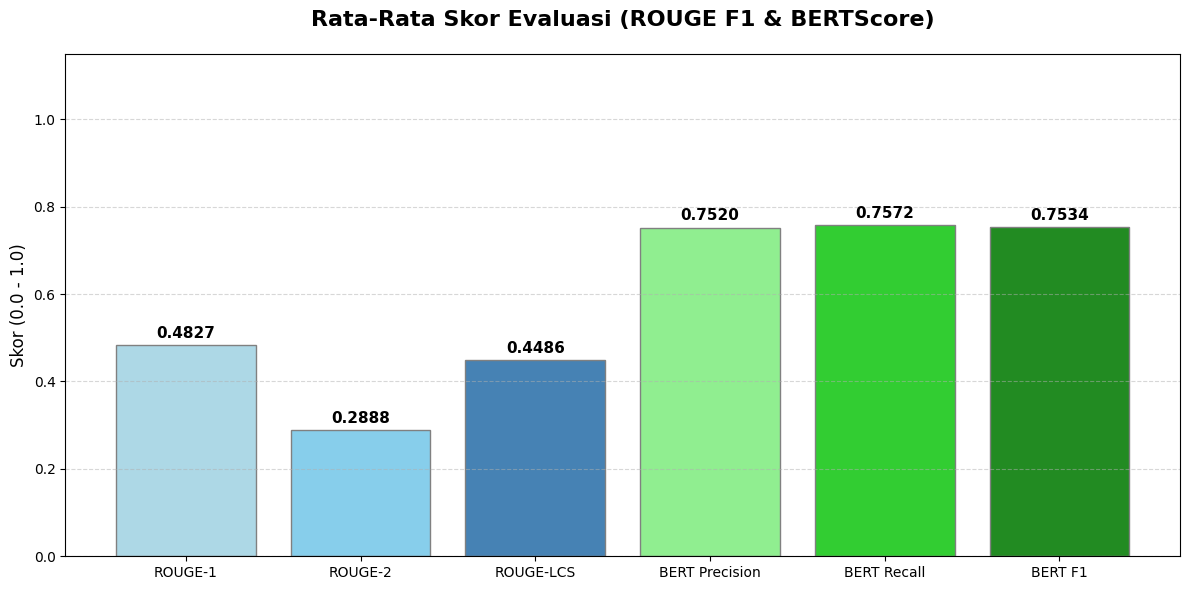

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("📊 Sedang men-generate grafik rata-rata...")

# 1. Siapkan Data average
metrics_data = {
    'ROUGE-1': df['R1_F1'].mean(),      
    'ROUGE-2': df['R2_F1'].mean(),      
    'ROUGE-LCS': df['RL_F1'].mean(),    
    'BERT Precision': df['BERT_Precision'].mean(),
    'BERT Recall': df['BERT_Recall'].mean(),
    'BERT F1': df['BERT_F1'].mean()
}

names = list(metrics_data.keys())
values = list(metrics_data.values())

# 2. Konfigurasi Plot ukuran
plt.figure(figsize=(12, 6)) 

# Warna
colors = ['#ADD8E6', '#87CEEB', '#4682B4', '#90EE90', '#32CD32', '#228B22']

bars = plt.bar(names, values, color=colors, edgecolor='grey')

# 3. show label 
for bar in bars:
    yval = bar.get_height()
    # angka dengan 4 desimal
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.4f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. visualisasi
plt.title('Rata-Rata Skor Evaluasi (ROUGE F1 & BERTScore)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Skor (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.15) # Ditinggikan sedikit biar angka tidak kepotong
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Tampilkan dan Simpan
plt.tight_layout()

# Simpan gambar
#output_img = 'Grafik_Evaluasi_RataRata_Final.png'
#plt.savefig(output_img, dpi=300) 
#print(f"✅ Grafik berhasil disimpan sebagai '{output_img}'")

plt.show()

In [ ]:
print("💾 Sedang memproses penyimpanan file 'Result-Intrinsic-evaluation.xlsx'...")

# 1. Urutan kolom yang ingin diambil dari DataFrame 'df'
target_columns = [
    'Kode',
    'Pertanyaan User',
    'Jawaban Chatbot',
    'Kalimat Referensi',
    
    # ROUGE-1 Breakdown
    'R1_Precision', 'R1_Recall', 'R1_F1',
    
    # ROUGE-2 Breakdown
    'R2_Precision', 'R2_Recall', 'R2_F1',
    
    # ROUGE-L (LCS) Breakdown
    'RL_Precision', 'RL_Recall', 'RL_F1',
    
    # BERTScore Breakdown
    'BERT_Precision', 'BERT_Recall', 'BERT_F1'
]

# 2. show hanya kolom yang ada di df
available_columns = [col for col in target_columns if col in df.columns]
result_df = df[available_columns].copy()

# 3. Rename Kolom dari df ke tabel yang rapih
result_df = result_df.rename(columns={
    'Pertanyaan User': 'Pertanyaan',
    'Jawaban Chatbot': 'Jawaban Model (Prediksi)',
    'Kalimat Referensi': 'Kunci Jawaban (Referensi)',
    
    # ROUGE-1
    'R1_Precision': 'ROUGE-1 Precision',
    'R1_Recall': 'ROUGE-1 Recall',
    'R1_F1': 'ROUGE-1 F-Measure',
    
    # ROUGE-2
    'R2_Precision': 'ROUGE-2 Precision',
    'R2_Recall': 'ROUGE-2 Recall',
    'R2_F1': 'ROUGE-2 F-Measure',
    
    # ROUGE-L
    'RL_Precision': 'ROUGE-L Precision',
    'RL_Recall': 'ROUGE-L Recall',
    'RL_F1': 'ROUGE-L F-Measure',
    
    # BERTScore
    'BERT_Precision': 'BERT Precision',
    'BERT_Recall': 'BERT Recall',
    'BERT_F1': 'BERT F1-Score'
})

# 4. tambah kolom nomor
result_df.insert(0, 'No', range(1, len(result_df) + 1))

# 5. Format Angkase mua skor menjadi 4 desimal
numeric_cols = result_df.select_dtypes(include=['number']).columns
# Kecuali kolom 'No', sisanya dibulatkan
cols_to_round = [col for col in numeric_cols if col != 'No']
result_df[cols_to_round] = result_df[cols_to_round].round(4)

# 6. Tampilkan Preview
print(f"\n✅ Data berhasil dikonsolidasi! Total: {len(result_df)} baris.")
display(result_df.head())

# 7. Simpan ke Excel Final
#output_filename = 'Result-Intrinsic-evaluation.xlsx'
#result_df.to_excel(output_filename, index=False)

#print(f"\n✅ SUKSES! File telah disimpan sebagai: {output_filename}")
#print("Silakan cek folder proyek Anda.")

💾 Sedang memproses penyimpanan file 'Result-Intrinsic-evaluation.xlsx'...

✅ Data berhasil dikonsolidasi! Total: 20 baris.


,No,Kode,Pertanyaan,Jawaban Model (Prediksi),Kunci Jawaban (Referensi),ROUGE-1 Precision,ROUGE-1 Recall,ROUGE-1 F-Measure,ROUGE-2 Precision,ROUGE-2 Recall,ROUGE-2 F-Measure,ROUGE-L Precision,ROUGE-L Recall,ROUGE-L F-Measure,BERT Precision,BERT Recall,BERT F1-Score
0,1,Q1,Draft judul SUP cukup berisi bab apa?,"Untuk pengajuan judul melalui PACIS, file draft SUP yang diunggah cukup berisi Bab 1 saja. Format yang dibutuhkan meliputi: Cover, Lembar pengesahan (sudah ditandatangani), dan Latar belakang (sekitar 3 lembar).","File draft SUP yang diupload cukup sampe bab 1 aja. Bab 1 nya juga ga perlu full, 3 lembar juga cukup – Formatnya : cover – lembar pengesahan (udah di TTD dosbing) – latar belakang",0.4667,0.4516,0.4590,0.2759,0.2667,0.2712,0.4000,0.3871,0.3934,0.7666,0.7496,0.7580
1,2,Q2,Minta link bit.ly untuk upload surat konversi magang yang sudah ditandatangani,Anda dapat mengunggah surat yang sudah ditandatangani dosen pembimbing magang melalui tautan berikut: https://bit.ly/UploadFormKonversiMagang,Surat yang sudah di tandatangan dosen pembimbing magang dapat di submit melalui link https://bit.ly/UploadFormKonversiMagang.,0.7059,0.7059,0.7059,0.4375,0.4375,0.4375,0.6471,0.6471,0.6471,0.8759,0.8974,0.8865
2,3,Q3,berapa SKS yang didapat buat mata kuliah Seminar Bisnis Digital dalam konversi magang?,Mata kuliah Seminar Bisnis Digital dalam konversi magang memiliki bobot 1 SKS. Hal ini berlaku untuk berbagai skema konversi (Magang Industri Digital maupun Usaha Rintisan).,SEMINAR BISNIS DIGITAL = 1 SKS,0.2000,1.0000,0.3333,0.1250,0.7500,0.2143,0.2000,1.0000,0.3333,0.6129,0.6367,0.6246
3,4,Q4,dimana saya bisa download PKS magang mandiri?,"Mohon maaf, saya tidak menemukan informasi mengenai tempat mengunduh PKS magang mandiri di dalam konteks yang tersedia. Anda bisa tanyakan langsung hal ini ke Bu Intan.",Untuk magang mandiri disertakan PKS magang untuk perusahaan yang dapat diakses pada : https://bit.ly/DataProdiBisdi,0.1538,0.2500,0.1905,0.0800,0.1333,0.1000,0.1154,0.1875,0.1429,0.6573,0.6203,0.6383
4,5,Q5,berapa total konversi SKS yang jika saya magang selama 6 bulan?,"Untuk durasi program magang selama 6 bulan, total konversi yang didapatkan setara dengan 20 SKS. Rincian: Magang Industri Digital (6 SKS), Softskill (2 SKS), Seminar (1 SKS), Matkul Pilihan (11 SKS).",TOTAL 20 sks — Durasi program selama 6 bulan setara dengan 20 SKS.,0.3548,0.9167,0.5116,0.2000,0.5455,0.2927,0.2903,0.7500,0.4186,0.6814,0.7713,0.7236



✅ SUKSES! File telah disimpan sebagai: Result-Intrinsic-evaluation.xlsx
Silakan cek folder proyek Anda.
